In [1]:
# ============================================================
# DAY 1 — CELL 1: Install All Required Packages — PINNED EXACT VERSIONS
# ============================================================
# Pinned to exact versions confirmed compatible with each other
# and with Kaggle's environment (CUDA 12.8, Python 3.12, NumPy 2.x)
# transformers 5.0.0 is pinned because kaggle-environments depends on it.
# All other versions pinned to match transformers 5.0.0 API.

!pip install -q \
    "transformers==5.0.0" \
    "datasets>=2.18.0" \
    "peft==0.18.1" \
    "trl==1.2.0" \
    "accelerate>=0.29.0" \
    "bitsandbytes==0.49.2" \
    "evaluate>=0.4.1" \
    "wandb>=0.17.0" \
    rouge_score \
    tabulate \
    tqdm \
    huggingface_hub

print("✅ All packages installed.")

# Verify exact versions loaded
import transformers, peft, trl, bitsandbytes
print(f"transformers:  {transformers.__version__}")
print(f"peft:          {peft.__version__}")
print(f"trl:           {trl.__version__}")
print(f"bitsandbytes:  {bitsandbytes.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 11.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
✅ All packages installed.
transformers:  5.0.0
peft:          0.18.1
trl:           1.2.0
bitsandbytes:  0.49.2


In [2]:
# ============================================================
# DAY 1 — CELL 1B: Load Dataset
# ============================================================
import os
import pandas as pd
from datasets import load_dataset

print("Loading dataset...")
dataset = load_dataset("b-mc2/sql-create-context")
print(f"✅ Loaded. Total examples: {len(dataset['train']):,}")

# Format — must match Day 1 Cell 5 exactly
def format_example(example):
    prompt = (
        f"### SQL Schema:\n"
        f"{example['context']}\n\n"
        f"### Question:\n"
        f"{example['question']}\n\n"
        f"### SQL Query:\n"
    )
    response = example['answer']
    return {
        "prompt":   prompt,
        "response": response,
        "text":     prompt + response + "</s>",
    }

print("Formatting dataset...")
dataset = dataset.map(format_example, desc="Formatting")

# Split — must match Day 1 Cell 6 exactly:
# shuffle(seed=42) FIRST, then train_test_split(test_size=0.05, seed=42)
full_data  = dataset['train'].shuffle(seed=42)
split      = full_data.train_test_split(test_size=0.05, seed=42)
train_data = split['train']
test_data  = split['test']

print(f"✅ Split complete.")
print(f"   Train: {len(train_data):,}")
print(f"   Test:  {len(test_data):,}")

# Verify first 50 test samples match saved baseline if file exists
BASELINE_FILE = "baseline_test_samples.csv"
if os.path.exists(BASELINE_FILE):
    baseline_df = pd.read_csv(BASELINE_FILE)
    first_question_saved  = baseline_df.iloc[0]['question']
    first_question_split  = test_data[0]['question']
    if first_question_saved == first_question_split:
        print("✅ Baseline test samples verified — split matches Day 1.")
    else:
        print("⚠️  WARNING: First question does not match saved baseline.")
        print(f"   Saved:  {first_question_saved[:80]}")
        print(f"   Current:{first_question_split[:80]}")
        print("   Check that format_example and split params match Day 1 exactly.")
else:
    print("ℹ️  baseline_test_samples.csv not found — skipping verification.")

print("✅ train_data and test_data ready. Proceed to Cell 2.")

Loading dataset...


✅ Loaded. Total examples: 78,577
Formatting dataset...
✅ Split complete.
   Train: 74,648
   Test:  3,929
✅ Baseline test samples verified — split matches Day 1.
✅ train_data and test_data ready. Proceed to Cell 2.


In [3]:
# ============================================================
# DAY 1 — CELL 2: Imports and GPU Verification
# ============================================================

import os
import gc
import json
import torch
import pandas as pd
from datetime import datetime
from tqdm import tqdm

# ── GPU CHECK ──────────────────────────────────────────────
print("=" * 50)
print("GPU HARDWARE CHECK")
print("=" * 50)
print(f"GPU available:     {torch.cuda.is_available()}")
print(f"Number of GPUs:    {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    name = torch.cuda.get_device_name(i)
    mem  = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"  GPU {i}: {name} ({mem:.1f} GB)")

print(f"CUDA version:      {torch.version.cuda}")
print(f"PyTorch version:   {torch.__version__}")
print("=" * 50)

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. Go to notebook Settings → Accelerator → GPU T4 x2 and restart."
    )

print("GPU is ready.")

GPU HARDWARE CHECK
GPU available:     True
Number of GPUs:    2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)
CUDA version:      12.8
PyTorch version:   2.10.0+cu128
GPU is ready.


In [4]:
# ============================================================
# DAY 1 — CELL 3: Weights & Biases Login
# ============================================================

import wandb
from kaggle_secrets import UserSecretsClient

# Retrieve the API key from Kaggle secrets (never hardcode it)
try:
    secrets = UserSecretsClient()
    wandb_key = secrets.get_secret("WANDB_API_KEY")
    wandb.login(key=wandb_key)
    print("✅ W&B login successful.")
except Exception as e:
    print(f"⚠️  Secret retrieval failed: {e}")
    print("Falling back to manual login — paste your key below:")
    wandb.login()  # Will prompt for key input

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: antonybryan2-00 (antonybryan2-00-anthropic) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ W&B login successful.


In [37]:
# ============================================================
# DAY 1 — CELL 4: Load Tokenizer + Base Model for Baseline Eval
# ============================================================
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch

model_name = "microsoft/phi-2"

# ── Tokenizer ────────────────────────────────────────────────────────
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"
print("✅ Tokenizer loaded.")

# ── Patch PhiConfig (transformers 5.0.0 bug) ─────────────────────────
config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
config.__dict__['pad_token_id'] = tokenizer.pad_token_id

# ── Load model in FP16 ───────────────────────────────────────────────
print("\nLoading Phi-2 in FP16 mode...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    config            = config,
    dtype             = torch.float16,   # torch_dtype deprecated in 5.0.0
    device_map        = "auto",
    trust_remote_code = True,
)
base_model.eval()
print("✅ Model loaded.")

print("\n📊 Memory after model load:")
for i in range(torch.cuda.device_count()):
    allocated = torch.cuda.memory_allocated(i) / 1e9
    reserved  = torch.cuda.memory_reserved(i)  / 1e9
    print(f"  GPU {i}: {allocated:.2f} GB allocated | {reserved:.2f} GB reserved")

Loading tokenizer...
✅ Tokenizer loaded.

Loading Phi-2 in FP16 mode...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

✅ Model loaded.

📊 Memory after model load:
  GPU 0: 9.35 GB allocated | 9.55 GB reserved
  GPU 1: 2.27 GB allocated | 4.28 GB reserved


In [38]:
# ============================================================
# DAY 1 — CELL 5: SQL Generation Function
# ============================================================

def generate_sql(model, tokenizer, prompt, max_new_tokens=150):
    """
    Generate a SQL query for a given prompt.

    Parameters:
        model         : The loaded Hugging Face model
        tokenizer     : The corresponding tokenizer
        prompt        : Formatted string (schema + question + "### SQL Query:")
        max_new_tokens: Max tokens to generate (150 is enough for most SQL)

    Returns:
        str: The generated SQL query (single line)
    """
    # Tokenize the prompt
    inputs = tokenizer(
        prompt,
        return_tensors = "pt",
        truncation     = True,
        max_length     = 512,     # Truncate very long schemas
    )

    # ── Critical: Place inputs on the correct GPU ───────────────────────
    # With device_map="auto", model.device returns 'meta' which is wrong.
    # Instead, find the device of the actual first embedding parameter.
    first_device = next(model.parameters()).device
    inputs = {k: v.to(first_device) for k, v in inputs.items()}

    with torch.no_grad():  # No gradient computation during inference
        outputs = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = False,              # Greedy decoding (deterministic)
            temperature    = 1.0,                # Ignored when do_sample=False
            pad_token_id   = tokenizer.eos_token_id,
            eos_token_id   = tokenizer.eos_token_id,
        )

    # Decode ONLY the generated part (not the input prompt)
    n_input_tokens = inputs['input_ids'].shape[1]
    generated_tokens = outputs[0][n_input_tokens:]
    result = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    # SQL is a single line — stop at first newline
    result = result.split('\n')[0].strip()
    return result


# ── Quick sanity test ──────────────────────────────────────────────────
test_prompt = (
    "### SQL Schema:\n"
    "CREATE TABLE students (id INT, name TEXT, grade FLOAT)\n\n"
    "### Question:\n"
    "What are the names of all students?\n\n"
    "### SQL Query:\n"
)

test_output = generate_sql(base_model, tokenizer, test_prompt)
print("📝 Test generation:")
print(f"   Input:  'What are the names of all students?'")
print(f"   Output: {test_output}")
print("\n✅ Generation function working.")

📝 Test generation:
   Input:  'What are the names of all students?'
   Output: SELECT name FROM students

✅ Generation function working.


In [39]:
# ============================================================
# DAY 1 — CELL 6: Baseline Evaluation — 50 Samples
# ============================================================

BASELINE_RESULTS_FILE = "baseline_results.csv"

if os.path.exists(BASELINE_RESULTS_FILE):
    print(f" Found existing {BASELINE_RESULTS_FILE} — skipping re-run.")
    baseline_results_df = pd.read_csv(BASELINE_RESULTS_FILE)
    baseline_exact_match = baseline_results_df['exact_match'].mean()
    print(f"   Baseline Exact Match: {baseline_exact_match:.4f} ({baseline_exact_match*100:.1f}%)")
else:
    print("Running baseline evaluation on 50 samples...")
    print("Expected time: ~15–30 minutes")
    print("─" * 50)

    baseline_results = []

    for i, sample in enumerate(tqdm(baseline_samples, desc="Baseline eval")):
        predicted_sql = generate_sql(base_model, tokenizer, sample['prompt'])
        ground_truth  = sample['answer']

        # Exact match: prediction must match ground truth exactly (case-insensitive)
        exact_match = predicted_sql.strip().lower() == ground_truth.strip().lower()

        baseline_results.append({
            'sample_idx':   i,
            'question':     sample['question'],
            'ground_truth': ground_truth,
            'predicted':    predicted_sql,
            'exact_match':  exact_match,
            'model':        'phi-2-base',
            'timestamp':    datetime.now().isoformat(),
        })

    # ── Save IMMEDIATELY (don't risk losing this to a timeout) ─────────
    baseline_results_df = pd.DataFrame(baseline_results)
    baseline_results_df.to_csv(BASELINE_RESULTS_FILE, index=False)

    baseline_exact_match = baseline_results_df['exact_match'].mean()
    n_correct = baseline_results_df['exact_match'].sum()

    print(f"\n{'='*50}")
    print("BASELINE RESULTS (Phi-2, No Fine-Tuning)")
    print(f"{'='*50}")
    print(f"  Correct:     {n_correct}/50")
    print(f"  Exact Match: {baseline_exact_match:.4f} ({baseline_exact_match*100:.1f}%)")
    print(f"  Saved to:    {BASELINE_RESULTS_FILE}")
    print(f"{'='*50}")
    print("\n Baseline complete. This is your 'before' measurement.")

 Found existing baseline_results.csv — skipping re-run.
   Baseline Exact Match: 0.0200 (2.0%)


In [40]:
# ============================================================
# DAY 1 — CELL 7: Day 1 Checkpoint — Print Summary
# ============================================================

print("=" * 60)
print("DAY 1 COMPLETE — CHECKPOINT SUMMARY")
print("=" * 60)
print(f"\n Baseline Results:")
print(f"   Model:       Phi-2 (base, no fine-tuning)")
print(f"   Dataset:     b-mc2/sql-create-context")
print(f"   Test set:    50 samples (seed=42, fixed)")
print(f"   Exact Match: {baseline_exact_match*100:.1f}%")

print(f"\n Files created:")
for f in ["baseline_test_samples.csv", "baseline_results.csv"]:
    exists = " EXISTS" if os.path.exists(f) else "❌ MISSING"
    print(f"   {exists} {f}")

print(f"\n Tomorrow (Day 2):")
print(f"   - Configure LoRA and fine-tune Phi-2 (2 training runs)")
print(f"   - Run 1: lr=2e-4 | Run 2: lr=5e-4")
print(f"   - Monitor training curves live on W&B")

print("\n" + "=" * 60)
print("IMPORTANT: Click 'Save' (top right) before closing this notebook.")
print("Your CSV files are saved in the Output tab of this notebook.")
print("=" * 60)

DAY 1 COMPLETE — CHECKPOINT SUMMARY

 Baseline Results:
   Model:       Phi-2 (base, no fine-tuning)
   Dataset:     b-mc2/sql-create-context
   Test set:    50 samples (seed=42, fixed)
   Exact Match: 2.0%

 Files created:
    EXISTS baseline_test_samples.csv
    EXISTS baseline_results.csv

 Tomorrow (Day 2):
   - Configure LoRA and fine-tune Phi-2 (2 training runs)
   - Run 1: lr=2e-4 | Run 2: lr=5e-4
   - Monitor training curves live on W&B

IMPORTANT: Click 'Save' (top right) before closing this notebook.
Your CSV files are saved in the Output tab of this notebook.


In [5]:
# ============================================================
# DAY 2 — CELL 1: Memory Cleanup
# ============================================================

import gc
import torch

# If base_model is still loaded from Day 1 in the same session, free it
try:
    del base_model
    print("Deleted base_model from memory.")
except NameError:
    print("base_model not in memory (OK if fresh session).")

gc.collect()
torch.cuda.empty_cache()

print("\n📊 GPU memory after cleanup:")
for i in range(torch.cuda.device_count()):
    allocated = torch.cuda.memory_allocated(i) / 1e9
    print(f"  GPU {i}: {allocated:.2f} GB allocated")

print("\n✅ Memory cleaned.")

base_model not in memory (OK if fresh session).

📊 GPU memory after cleanup:
  GPU 0: 0.00 GB allocated
  GPU 1: 0.00 GB allocated

✅ Memory cleaned.


In [6]:
# ============================================================
# DAY 2 — CELL 2: Load Phi-2 for Training (4-bit + bf16)
# ============================================================
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

model_name = "microsoft/phi-2"

# ── Tokenizer ────────────────────────────────────────────────────────
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"
print(f"✅ Tokenizer loaded. pad_token_id = {tokenizer.pad_token_id}")

# ── Patch PhiConfig ──────────────────────────────────────────────────
# transformers 5.0.0 PhiConfig is missing pad_token_id entirely.
# PhiModel.__init__ reads config.pad_token_id on line 348 and crashes.
# Fix: load config separately and inject pad_token_id into __dict__
# before passing it to from_pretrained.
print("Patching PhiConfig...")
config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
config.__dict__['pad_token_id'] = tokenizer.pad_token_id
print(f"✅ Config patched. pad_token_id = {config.__dict__.get('pad_token_id')}")

# ── Quantization ─────────────────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_compute_dtype    = torch.bfloat16,
    bnb_4bit_use_double_quant = True,
)

# ── Load model ───────────────────────────────────────────────────────
print("\nLoading Phi-2 in 4-bit across both GPUs...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    config              = config,
    quantization_config = bnb_config,
    device_map          = "auto",
    trust_remote_code   = True,
)
print(f"✅ Model loaded.")
print(f"   GPU 0: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
print(f"   GPU 1: {torch.cuda.memory_allocated(1)/1e9:.2f} GB")

# ── Prepare for k-bit training ───────────────────────────────────────
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)
print("✅ Model prepared. Proceed to Cell 3.")

Loading tokenizer...
✅ Tokenizer loaded. pad_token_id = 50256
Patching PhiConfig...
✅ Config patched. pad_token_id = 50256

Loading Phi-2 in 4-bit across both GPUs...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Model loaded.
   GPU 0: 0.59 GB
   GPU 1: 1.24 GB
✅ Model prepared. Proceed to Cell 3.


In [7]:
# ============================================================
# DAY 2 — CELL 3: Configure LoRA
# ============================================================
# Do NOT call get_peft_model() here.
# Per trl 1.2.0 canonical pattern: pass peft_config directly to
# SFTTrainer in Cell 5. SFTTrainer applies LoRA internally on the
# base model. Calling get_peft_model() first then passing peft_config
# causes "You passed a PeftModel with a peft_config" ValueError.
# ============================================================
from peft import LoraConfig, TaskType

lora_config = LoraConfig(
    r              = 16,
    lora_alpha     = 32,
    lora_dropout   = 0.05,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
    target_modules = ["q_proj", "v_proj"],
)

print("✅ LoRA config defined.")
print("   SFTTrainer will apply it in Cell 5 — do not call get_peft_model here.")
print("✅ Proceed to Cell 4.")

✅ LoRA config defined.
   SFTTrainer will apply it in Cell 5 — do not call get_peft_model here.
✅ Proceed to Cell 4.


In [8]:
# ============================================================
# DAY 2 — CELL 4: Validation Subset
# ============================================================

eval_subset = test_data.select(range(200))

# Strip to only "text" column before passing to SFTTrainer.
# Reason: TRL 1.2.0 completion_only_loss=None means auto-detect.
# Auto-detection sees "prompt" column and assumes prompt/completion
# format, then crashes looking for "completion". Keeping only "text"
# forces TRL into the standard language modeling path.
# 20,000 training samples selected — full 74k takes ~40hrs on T4x2.
# 20k × 2 epochs ≈ 7 hours, fits within Kaggle's 12hr session limit.
train_data_sft = train_data.select(range(20000)).select_columns(["text"])
eval_data_sft  = eval_subset.select_columns(["text"])

print(f"✅ Eval subset:          {len(eval_data_sft)} samples")
print(f"   Train set (full):     {len(train_data):,} samples")
print(f"   Train set (SFT):      {len(train_data_sft):,} samples")
print(f"   train_data_sft cols:  {train_data_sft.column_names}")
print(f"   eval_data_sft cols:   {eval_data_sft.column_names}")

# Expected: steps_per_epoch = ceil(20000/16) = 1250
# Total steps = 1250 × 2 = 2500 ≈ 6.9 hours at 0.10 it/s
print(f"\n   Expected steps/epoch: {-(-20000//16)}")
print(f"   Expected total steps: {-(-20000//16) * 2}")
print(f"   Estimated time:       ~7 hours")

assert train_data_sft.column_names == ["text"], "❌ train_data_sft should only have 'text'"
assert eval_data_sft.column_names  == ["text"], "❌ eval_data_sft should only have 'text'"
print("\n✅ Column check passed. Proceed to Cell 5.")

✅ Eval subset:          200 samples
   Train set (full):     74,648 samples
   Train set (SFT):      20,000 samples
   train_data_sft cols:  ['text']
   eval_data_sft cols:   ['text']

   Expected steps/epoch: 1250
   Expected total steps: 2500
   Estimated time:       ~7 hours

✅ Column check passed. Proceed to Cell 5.


In [ ]:
# ============================================================
# DAY 2 — CELL 5: Training Run 1 — Learning Rate 2e-4
# ============================================================
import os
import torch
import wandb
from trl import SFTTrainer, SFTConfig

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

try:
    wandb.finish()
except:
    pass

RUN1_OUTPUT_DIR = "./phi2-sql-lora-run1"
RUN1_FINAL_DIR  = "./phi2-sql-lora-run1-final"

# ── W&B ──────────────────────────────────────────────────────────────
wandb.init(
    project = "phi2-sql-finetune",
    name    = "run1-lr2e4-20k-2ep",
    config  = {
        "model":           "phi-2",
        "dataset":         "sql-create-context",
        "train_samples":   20000,
        "lora_r":          16,
        "lora_alpha":      32,
        "learning_rate":   2e-4,
        "epochs":          2,
        "effective_batch": 16,
        "quantization":    "4bit-nf4",
        "precision":       "bf16",
        "transformers":    "5.0.0",
        "trl":             "1.2.0",
        "peft":            "0.18.1",
    },
)

# ── SFTConfig ─────────────────────────────────────────────────────────
# num_train_epochs=2: 20k samples × 2 epochs ≈ 7hrs on T4x2
# save_strategy="steps" + save_steps=500: gives recovery checkpoints
#   within each epoch. With epoch-based saving you only get 2 saves
#   total — if session times out at step 2400 you lose everything.
# eval_strategy="steps" + eval_steps=500: matches save cadence so
#   W&B shows eval loss curve across training not just at epoch end.
# dataset_text_field="text": works correctly because train_data_sft
#   has only the "text" column — no "prompt" column to confuse TRL.
# bf16=True, fp16=False: matches LoRA adapter dtype.
# gradient_checkpointing=False: avoids CheckpointError on recompute.
training_args_run1 = SFTConfig(
    dataset_text_field          = "text",
    max_length                  = 256,

    output_dir                  = RUN1_OUTPUT_DIR,
    num_train_epochs            = 2,
    per_device_train_batch_size = 2,
    per_device_eval_batch_size  = 1,
    gradient_accumulation_steps = 8,
    eval_accumulation_steps     = 4,
    learning_rate               = 2e-4,
    weight_decay                = 0.001,
    fp16                        = False,
    bf16                        = True,
    gradient_checkpointing      = False,
    logging_steps               = 50,
    save_strategy               = "steps",
    save_steps                  = 500,
    save_total_limit            = 3,        # keep only last 3 checkpoints to save disk
    eval_strategy               = "steps",
    eval_steps                  = 500,
    load_best_model_at_end      = False,
    warmup_steps                = 100,
    lr_scheduler_type           = "cosine",
    report_to                   = "wandb",
    run_name                    = "run1-lr2e4-20k-2ep",
    dataloader_num_workers      = 0,
    optim                       = "paged_adamw_8bit",
)

# ── SFTTrainer ────────────────────────────────────────────────────────
trainer_run1 = SFTTrainer(
    model         = model,
    train_dataset = train_data_sft,
    eval_dataset  = eval_data_sft,
    peft_config   = lora_config,
    args          = training_args_run1,
)

# ── Pre-flight check ─────────────────────────────────────────────────
trainable = [(n, p) for n, p in trainer_run1.model.named_parameters()
             if p.requires_grad]
if len(trainable) == 0:
    raise RuntimeError("❌ No trainable params. Re-run Cells 2–3.")

dtypes = {p.dtype for _, p in trainable}
print(f"✅ Pre-flight passed.")
print(f"   Trainable params:  {len(trainable)}")
print(f"   Dtypes:            {dtypes}")
print(f"   Train samples:     {len(train_data_sft):,}")
print(f"   Eval samples:      {len(eval_data_sft):,}")
print(f"   Epochs:            2")
print(f"   Steps/epoch:       {-(-len(train_data_sft)//16)}")
print(f"   Total steps:       {-(-len(train_data_sft)//16) * 2}")
print(f"\n   📊 Watch live: https://wandb.ai → 'phi2-sql-finetune'")
print("─" * 50)

# ── Train ─────────────────────────────────────────────────────────────
trainer_run1.train()
trainer_run1.save_model(RUN1_FINAL_DIR)
tokenizer.save_pretrained(RUN1_FINAL_DIR)
wandb.finish()

print(f"\n✅ Run 1 complete. Adapter saved to: {RUN1_FINAL_DIR}")

In [9]:
# ============================================================
# DAY 2 — CELL 6: Memory Cleanup Between Run 1 and Run 2
# ============================================================
# Drops Run 1 model + trainer, frees GPU memory before loading
# fresh Phi-2 for Run 2. Keep train_data_sft and eval_data_sft —
# they are reused in Run 2.
# ============================================================
import gc
import torch
import wandb

try:
    wandb.finish()
except:
    pass

# Drop large objects
try:
    del trainer_run1
except NameError:
    pass

try:
    del model
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

print("📊 GPU memory after cleanup:")
for i in range(torch.cuda.device_count()):
    allocated = torch.cuda.memory_allocated(i) / 1e9
    reserved  = torch.cuda.memory_reserved(i) / 1e9
    print(f"   GPU {i}: allocated={allocated:.2f} GB, reserved={reserved:.2f} GB")

print("\n✅ Memory cleared. Ready for Cell 7 (reload fresh Phi-2 for Run 2).")

📊 GPU memory after cleanup:
   GPU 0: allocated=0.00 GB, reserved=0.00 GB
   GPU 1: allocated=0.00 GB, reserved=0.00 GB

✅ Memory cleared. Ready for Cell 7 (reload fresh Phi-2 for Run 2).


In [10]:
# ============================================================
# DAY 2 — CELL 7: Reload Fresh Phi-2 for Run 2
# ============================================================
# Must load from original base model, NOT from Run 1 checkpoint.
# Exact same loading pattern as Cell 2:
#   - Config patch for pad_token_id (transformers 5.0.0 quirk)
#   - bf16 compute dtype
#   - gradient_checkpointing=False
#   - Do NOT call get_peft_model() — peft_config passed to SFTTrainer
# ============================================================
import os
import torch
from transformers import (
    AutoModelForCausalLM, AutoConfig, BitsAndBytesConfig
)
from peft import prepare_model_for_kbit_training

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ── Patch config again (previous one was garbage collected) ──────────
print("Patching PhiConfig for Run 2...")
config2 = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
config2.__dict__['pad_token_id'] = tokenizer.pad_token_id
print(f"✅ Config patched. pad_token_id = {config2.__dict__.get('pad_token_id')}")

# ── Quantization (same as Run 1) ─────────────────────────────────────
bnb_config2 = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_compute_dtype    = torch.bfloat16,
    bnb_4bit_use_double_quant = True,
)

# ── Load fresh model ─────────────────────────────────────────────────
print("\nLoading fresh Phi-2 for Run 2...")
model2 = AutoModelForCausalLM.from_pretrained(
    model_name,
    config              = config2,
    quantization_config = bnb_config2,
    device_map          = "auto",
    trust_remote_code   = True,
)
print(f"✅ Model 2 loaded.")
print(f"   GPU 0: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
print(f"   GPU 1: {torch.cuda.memory_allocated(1)/1e9:.2f} GB")

# ── Prepare for k-bit training ───────────────────────────────────────
model2 = prepare_model_for_kbit_training(model2, use_gradient_checkpointing=False)
print("✅ Model 2 prepared. Proceed to Cell 8.")

Patching PhiConfig for Run 2...
✅ Config patched. pad_token_id = 50256

Loading fresh Phi-2 for Run 2...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

✅ Model 2 loaded.
   GPU 0: 0.59 GB
   GPU 1: 1.24 GB
✅ Model 2 prepared. Proceed to Cell 8.


In [ ]:
# ============================================================
# DAY 2 — CELL 8: Training Run 2 — Learning Rate 5e-4
# ============================================================
# Only learning_rate differs from Run 1 — everything else identical.
# Reuses train_data_sft and eval_data_sft from Cell 4 (text-only).
# ============================================================
import os
import torch
import wandb
from trl import SFTTrainer, SFTConfig

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

try:
    wandb.finish()
except:
    pass

RUN2_OUTPUT_DIR = "./phi2-sql-lora-run2"
RUN2_FINAL_DIR  = "./phi2-sql-lora-run2-final"

# ── W&B ──────────────────────────────────────────────────────────────
wandb.init(
    project = "phi2-sql-finetune",
    name    = "run2-lr5e4-20k-2ep",
    config  = {
        "model":           "phi-2",
        "dataset":         "sql-create-context",
        "train_samples":   20000,
        "lora_r":          16,
        "lora_alpha":      32,
        "learning_rate":   5e-4,    # ← only change from Run 1
        "epochs":          2,
        "effective_batch": 16,
        "quantization":    "4bit-nf4",
        "precision":       "bf16",
        "transformers":    "5.0.0",
        "trl":             "1.2.0",
        "peft":            "0.18.1",
    },
)

# ── SFTConfig ─────────────────────────────────────────────────────────
training_args_run2 = SFTConfig(
    dataset_text_field          = "text",
    max_length                  = 256,

    output_dir                  = RUN2_OUTPUT_DIR,
    num_train_epochs            = 2,
    per_device_train_batch_size = 2,
    per_device_eval_batch_size  = 1,
    gradient_accumulation_steps = 8,
    eval_accumulation_steps     = 4,
    learning_rate               = 5e-4,    # ← only change from Run 1
    weight_decay                = 0.001,
    fp16                        = False,
    bf16                        = True,
    gradient_checkpointing      = False,
    logging_steps               = 50,
    save_strategy               = "steps",
    save_steps                  = 500,
    save_total_limit            = 3,
    eval_strategy               = "steps",
    eval_steps                  = 500,
    load_best_model_at_end      = False,
    warmup_steps                = 100,
    lr_scheduler_type           = "cosine",
    report_to                   = "wandb",
    run_name                    = "run2-lr5e4-20k-2ep",
    dataloader_num_workers      = 0,
    optim                       = "paged_adamw_8bit",
)

# ── SFTTrainer ────────────────────────────────────────────────────────
trainer_run2 = SFTTrainer(
    model         = model2,
    train_dataset = train_data_sft,
    eval_dataset  = eval_data_sft,
    peft_config   = lora_config,
    args          = training_args_run2,
)

# ── Pre-flight check ─────────────────────────────────────────────────
trainable = [(n, p) for n, p in trainer_run2.model.named_parameters()
             if p.requires_grad]
if len(trainable) == 0:
    raise RuntimeError("❌ No trainable params. Re-run Cells 6–7.")

dtypes = {p.dtype for _, p in trainable}
print(f"✅ Pre-flight passed.")
print(f"   Trainable params:  {len(trainable)}")
print(f"   Dtypes:            {dtypes}")
print(f"   Learning rate:     5e-4")
print(f"   Train samples:     {len(train_data_sft):,}")
print(f"   Steps/epoch:       {-(-len(train_data_sft)//16)}")
print(f"   Total steps:       {-(-len(train_data_sft)//16) * 2}")
print(f"\n   📊 Watch live: https://wandb.ai → 'phi2-sql-finetune'")
print("─" * 50)

# ── Train ─────────────────────────────────────────────────────────────
trainer_run2.train()
trainer_run2.save_model(RUN2_FINAL_DIR)
tokenizer.save_pretrained(RUN2_FINAL_DIR)
wandb.finish()

print(f"\n✅ Run 2 complete. Adapter saved to: {RUN2_FINAL_DIR}")

In [43]:
# ============================================================
# DAY 2 — CELL 9: Day 2 Checkpoint
# ============================================================
import os

print("=" * 60)
print("DAY 2 COMPLETE — CHECKPOINT SUMMARY")
print("=" * 60)

# Adapters may be in /kaggle/working (same session) or
# /kaggle/input (added as dataset from previous version)
ADAPTER_SEARCH_PATHS = [
    ("phi2-sql-lora-run1-final", [
        "./phi2-sql-lora-run1-final",
        "/kaggle/input/datasets/antonybryan/run-1-results/phi2-sql-lora-run1-final",
    ]),
    ("phi2-sql-lora-run2-final", [
        "./phi2-sql-lora-run2-final",
        "/kaggle/input/datasets/antonybryan/run-2-results/phi2-sql-lora-run2-final",
    ]),
]

all_ok = True
for name, paths in ADAPTER_SEARCH_PATHS:
    found = False
    for path in paths:
        cfg = os.path.join(path, "adapter_config.json")
        if os.path.exists(cfg):
            size_mb = sum(
                os.path.getsize(os.path.join(path, f))
                for f in os.listdir(path)
                if os.path.isfile(os.path.join(path, f))
            ) / 1e6
            print(f"   ✅ {name}/  ({size_mb:.1f} MB)")
            print(f"      Location: {path}")
            found = True
            break
    if not found:
        print(f"   ❌ {name}/ MISSING in all search paths")
        all_ok = False

if all_ok:
    print("\n✅ Both adapters confirmed. Ready to proceed to Day 3.")
else:
    print("\n⚠️  Some outputs missing — check training logs before proceeding.")
print("=" * 60)

DAY 2 COMPLETE — CHECKPOINT SUMMARY
   ✅ phi2-sql-lora-run1-final/  (14.1 MB)
      Location: /kaggle/input/datasets/antonybryan/run-1-results/phi2-sql-lora-run1-final
   ✅ phi2-sql-lora-run2-final/  (14.1 MB)
      Location: /kaggle/input/datasets/antonybryan/run-2-results/phi2-sql-lora-run2-final

✅ Both adapters confirmed. Ready to proceed to Day 3.


In [12]:
# ============================================================
# DAY 3 — CELL 1: Load All Three Models for Evaluation
# ============================================================
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
from peft import PeftModel

model_name = "microsoft/phi-2"

# Confirmed adapter paths from /kaggle/input
RUN1_ADAPTER = "/kaggle/input/datasets/antonybryan/run-1-results/phi2-sql-lora-run1-final"
RUN2_ADAPTER = "/kaggle/input/datasets/antonybryan/run-2-results/phi2-sql-lora-run2-final"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# ── Helper: load base model in fp16 with PhiConfig patch ─────────────
def load_base_fp16():
    cfg = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
    cfg.__dict__['pad_token_id'] = tokenizer.pad_token_id
    return AutoModelForCausalLM.from_pretrained(
        model_name,
        config            = cfg,
        torch_dtype       = torch.float16,
        device_map        = "auto",
        trust_remote_code = True,
    )

# ── Base model ───────────────────────────────────────────────────────
print("Loading base model...")
base_eval_model = load_base_fp16()
base_eval_model.eval()
print("✅ Base model loaded.")

# ── Run 1 ────────────────────────────────────────────────────────────
print("\nLoading Run 1 fine-tuned model...")
base_for_run1  = load_base_fp16()
finetuned_run1 = PeftModel.from_pretrained(base_for_run1, RUN1_ADAPTER)
finetuned_run1.eval()
print("✅ Run 1 model loaded.")

# ── Run 2 ────────────────────────────────────────────────────────────
print("\nLoading Run 2 fine-tuned model...")
base_for_run2  = load_base_fp16()
finetuned_run2 = PeftModel.from_pretrained(base_for_run2, RUN2_ADAPTER)
finetuned_run2.eval()
print("✅ Run 2 model loaded.")

print("\n✅ All three models ready for evaluation.")

Loading base model...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

✅ Base model loaded.

Loading Run 1 fine-tuned model...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

✅ Run 1 model loaded.

Loading Run 2 fine-tuned model...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

✅ Run 2 model loaded.

✅ All three models ready for evaluation.


In [13]:
# ============================================================
# DAY 3 — CELL 2: Evaluation Metrics
# ============================================================
import evaluate

def exact_match_score(predictions, references):
    matches = sum(
        p.strip().lower() == r.strip().lower()
        for p, r in zip(predictions, references)
    )
    return matches / len(predictions)

rouge = evaluate.load("rouge")

def rouge_l_score(predictions, references):
    results = rouge.compute(predictions=predictions, references=references)
    return results['rougeL']

print("✅ Metrics ready.")
print("   Metric 1: Exact Match (primary)")
print("   Metric 2: ROUGE-L (secondary)")

✅ Metrics ready.
   Metric 1: Exact Match (primary)
   Metric 2: ROUGE-L (secondary)


In [20]:
# ============================================================
# DAY 3 — CELL 3: generate_sql function + load baseline samples
# ============================================================
import os
import torch
import pandas as pd

def generate_sql(model, tokenizer, prompt, max_new_tokens=150):
    inputs = tokenizer(
        prompt,
        return_tensors = "pt",
        truncation     = True,
        max_length     = 512,
    )
    first_device = next(model.parameters()).device
    inputs = {k: v.to(first_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            do_sample      = False,
            pad_token_id   = tokenizer.eos_token_id,
            eos_token_id   = tokenizer.eos_token_id,
        )

    n_input = inputs['input_ids'].shape[1]
    result  = tokenizer.decode(outputs[0][n_input:], skip_special_tokens=True)

    # Explicitly strip residual special tokens that skip_special_tokens
    # misses on Phi-2 (</s> and <|endoftext|> survive decoding)
    result = result.replace("</s>", "").replace("<|endoftext|>", "")
    result = result.split('\n')[0].strip()
    return result

# ── Load 50-sample baseline ──────────────────────────────────────────
BASELINE_FILE = "baseline_test_samples.csv"
if not os.path.exists(BASELINE_FILE):
    raise FileNotFoundError(
        f"❌ {BASELINE_FILE} not found. Day 1 must have been run first."
    )

baseline_df = pd.read_csv(BASELINE_FILE)
baseline_samples_list = baseline_df.to_dict('records')
print(f"✅ Loaded {len(baseline_samples_list)} baseline samples.")
print("✅ generate_sql ready.")

✅ Loaded 50 baseline samples.
✅ generate_sql ready.


In [24]:
# ============================================================
# DAY 3 — CELL 4: Run Full Evaluation on All Three Models
# ~15-30 minutes total on T4 (50 samples × 3 models)
# ============================================================
import os
import pandas as pd
from tqdm import tqdm

def evaluate_model(model, tokenizer, samples, model_tag, save_file):
    # Cache-aware: if predictions already exist, load them
    if os.path.exists(save_file):
        print(f"📂 Found {save_file} — loading cached results.")
        df     = pd.read_csv(save_file)
        preds  = df['predicted'].tolist()
        truths = df['ground_truth'].tolist()
        em     = exact_match_score(preds, truths)
        rl     = rouge_l_score(preds, truths)
        print(f"   {model_tag}: EM={em:.4f}, ROUGE-L={rl:.4f}")
        return {
            "model":         model_tag,
            "exact_match":   em,
            "rouge_l":       rl,
            "predictions":   preds,
            "ground_truths": truths,
        }

    print(f"\nEvaluating: {model_tag}")
    predictions, ground_truths = [], []

    for sample in tqdm(samples, desc=model_tag):
        prompt = sample['prompt']
        answer = sample['answer']
        pred   = generate_sql(model, tokenizer, prompt)
        predictions.append(pred)
        ground_truths.append(answer)

    em = exact_match_score(predictions, ground_truths)
    rl = rouge_l_score(predictions, ground_truths)

    df = pd.DataFrame({
        'question':     [s['question'] for s in samples],
        'ground_truth': ground_truths,
        'predicted':    predictions,
        'exact_match':  [p.strip().lower() == g.strip().lower()
                         for p, g in zip(predictions, ground_truths)],
        'model':        model_tag,
    })
    df.to_csv(save_file, index=False)
    print(f"   ✅ {model_tag}: EM={em:.4f} ({em*100:.1f}%), ROUGE-L={rl:.4f}")
    return {
        "model":         model_tag,
        "exact_match":   em,
        "rouge_l":       rl,
        "predictions":   predictions,
        "ground_truths": ground_truths,
    }

all_results = {}
all_results['base'] = evaluate_model(
    base_eval_model, tokenizer, baseline_samples_list,
    "phi2-base", "predictions_base.csv"
)
all_results['run1'] = evaluate_model(
    finetuned_run1,  tokenizer, baseline_samples_list,
    "phi2-sql-lora-run1", "predictions_run1.csv"
)
all_results['run2'] = evaluate_model(
    finetuned_run2,  tokenizer, baseline_samples_list,
    "phi2-sql-lora-run2", "predictions_run2.csv"
)

print("\n✅ All evaluations complete.")


Evaluating: phi2-base



phi2-base: 100%|██████████| 50/50 [04:56<00:00,  5.93s/it]


   ✅ phi2-base: EM=0.0200 (2.0%), ROUGE-L=0.8860

Evaluating: phi2-sql-lora-run1



phi2-sql-lora-run1: 100%|██████████| 50/50 [01:14<00:00,  1.49s/it]


   ✅ phi2-sql-lora-run1: EM=0.7600 (76.0%), ROUGE-L=0.9903

Evaluating: phi2-sql-lora-run2



phi2-sql-lora-run2: 100%|██████████| 50/50 [01:15<00:00,  1.50s/it]

   ✅ phi2-sql-lora-run2: EM=0.7000 (70.0%), ROUGE-L=0.9825

✅ All evaluations complete.


In [25]:
# ============================================================
# DAY 3 — CELL 5: Results Summary Table
# ============================================================
import pandas as pd

base_em = all_results['base']['exact_match']
run1_em = all_results['run1']['exact_match']
run2_em = all_results['run2']['exact_match']
base_rl = all_results['base']['rouge_l']
run1_rl = all_results['run1']['rouge_l']
run2_rl = all_results['run2']['rouge_l']

summary = pd.DataFrame([
    {
        "Model":       "Phi-2 Base",
        "LR":          "—",
        "Exact Match": f"{base_em*100:.1f}%",
        "ROUGE-L":     f"{base_rl:.4f}",
        "Δ vs Base":   "—",
    },
    {
        "Model":       "Phi-2 + LoRA (Run 1)",
        "LR":          "2e-4",
        "Exact Match": f"{run1_em*100:.1f}%",
        "ROUGE-L":     f"{run1_rl:.4f}",
        "Δ vs Base":   f"+{(run1_em-base_em)*100:.1f}pp",
    },
    {
        "Model":       "Phi-2 + LoRA (Run 2)",
        "LR":          "5e-4",
        "Exact Match": f"{run2_em*100:.1f}%",
        "ROUGE-L":     f"{run2_rl:.4f}",
        "Δ vs Base":   f"+{(run2_em-base_em)*100:.1f}pp",
    },
])
summary.to_csv("results_summary.csv", index=False)

print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)
print(summary.to_markdown(index=False))

best_run = "run1" if run1_em >= run2_em else "run2"
best_em  = max(run1_em, run2_em)
best_lr  = "2e-4" if best_run == "run1" else "5e-4"
print(f"\nBest run: {best_run} (lr={best_lr}), EM={best_em*100:.1f}%")
print(f"Total improvement: +{(best_em-base_em)*100:.1f} percentage points")

FINAL RESULTS
| Model                | LR   | Exact Match   |   ROUGE-L | Δ vs Base   |
|:---------------------|:-----|:--------------|----------:|:------------|
| Phi-2 Base           | —    | 2.0%          |    0.886  | —           |
| Phi-2 + LoRA (Run 1) | 2e-4 | 76.0%         |    0.9903 | +74.0pp     |
| Phi-2 + LoRA (Run 2) | 5e-4 | 70.0%         |    0.9825 | +68.0pp     |

Best run: run1 (lr=2e-4), EM=76.0%
Total improvement: +74.0 percentage points


In [28]:
# ============================================================
# DAY 3 — CELL 6: Qualitative Analysis
# ============================================================
import pandas as pd

base_df = pd.read_csv("predictions_base.csv")
best_df = pd.read_csv(f"predictions_{best_run}.csv")

# Clean residual </s> tokens from saved predictions
# (predictions saved before generate_sql fix may have them)
for df in [base_df, best_df]:
    df['predicted'] = df['predicted'].str.replace("</s>", "", regex=False)
    df['predicted'] = df['predicted'].str.replace("<|endoftext|>", "", regex=False)
    df['predicted'] = df['predicted'].str.strip()
    # Recompute exact_match after cleaning
    df['exact_match'] = (
        df['predicted'].str.strip().str.lower() ==
        df['ground_truth'].str.strip().str.lower()
    )

# Reset indices to ensure alignment
base_df = base_df.reset_index(drop=True)
best_df = best_df.reset_index(drop=True)

# Recompute improvement/regression masks
improved_mask  = (best_df['exact_match'] == True)  & (base_df['exact_match'] == False)
regressed_mask = (best_df['exact_match'] == False) & (base_df['exact_match'] == True)

improved  = best_df[improved_mask].head(5)
regressed = best_df[regressed_mask].head(5)

print(f"Total improved:  {improved_mask.sum()} cases (base wrong → FT right)")
print(f"Total regressed: {regressed_mask.sum()} cases (base right → FT wrong)")

print("\n" + "=" * 70)
print(f"CASES WHERE FINE-TUNING HELPED ({len(improved)} shown)")
print("=" * 70)
for idx, row in improved.iterrows():
    print(f"\n  Q: {row['question']}")
    print(f"  GT:   {row['ground_truth']}")
    print(f"  Base: {base_df.loc[idx, 'predicted']}")
    print(f"  FT:   {row['predicted']}")

print(f"\n{'='*70}")
print(f"CASES WHERE FINE-TUNING HURT ({len(regressed)} shown)")
print("=" * 70)
for idx, row in regressed.iterrows():
    print(f"\n  Q: {row['question']}")
    print(f"  GT:   {row['ground_truth']}")
    print(f"  Base: {base_df.loc[idx, 'predicted']}")
    print(f"  FT:   {row['predicted']}")

# Print updated scores after cleaning
em_base = base_df['exact_match'].mean()
em_best = best_df['exact_match'].mean()
print(f"\n📊 Cleaned scores:")
print(f"   Base EM:       {em_base*100:.1f}%")
print(f"   {best_run} EM: {em_best*100:.1f}%")
print(f"   Improvement:   +{(em_best-em_base)*100:.1f}pp")

Total improved:  37 cases (base wrong → FT right)
Total regressed: 0 cases (base right → FT wrong)

CASES WHERE FINE-TUNING HELPED (5 shown)

  Q: Tell me the height which has a surpassed by of book tower
  GT:   SELECT height_feet_m FROM table_name_2 WHERE surpassed_by = "book tower"
  Base: SELECT height_feet_m FROM table_name_2 WHERE surpassed_by = 'book tower';
  FT:   SELECT height_feet_m FROM table_name_2 WHERE surpassed_by = "book tower"

  Q: Who is the h.h. principal with Jim Haught as h.s. principal, Charlie Taylor as maplemere principal, and Rich Auerbach as w.r. principal?
  GT:   SELECT hh_principal FROM table_name_55 WHERE hs_principal = "jim haught" AND maplemere_principal = "charlie taylor" AND wr_principal = "rich auerbach"
  Base: SELECT hh_principal, wr_principal, hs_principal, maplemere_principal
  FT:   SELECT hh_principal FROM table_name_55 WHERE hs_principal = "jim haught" AND maplemere_principal = "charlie taylor" AND wr_principal = "rich auerbach"

  Q: What is

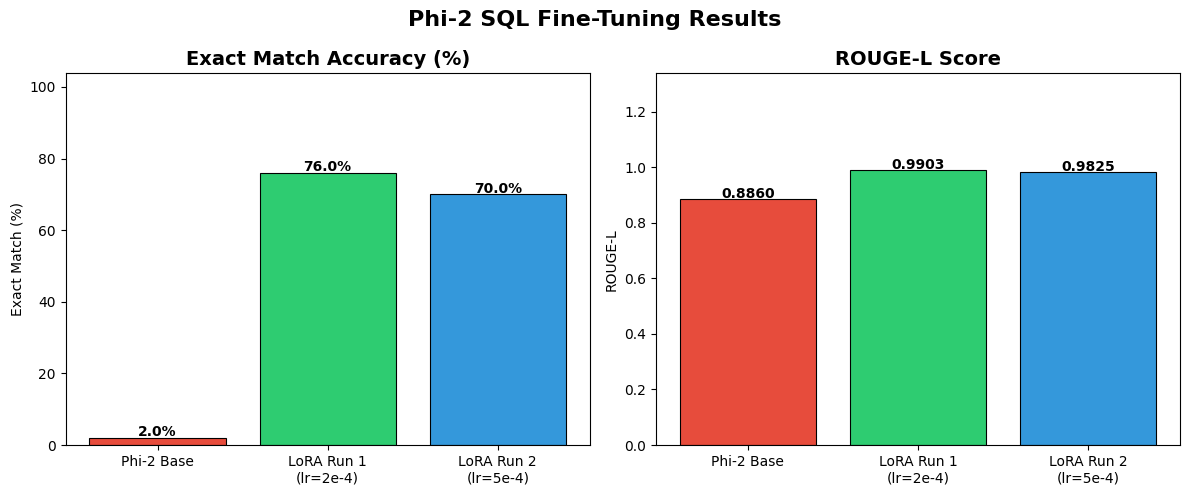

✅ Chart saved to charts/results_comparison.png


In [26]:
# ============================================================
# DAY 3 — CELL 7: Results Comparison Chart
# ============================================================
import os
import matplotlib.pyplot as plt

models  = ["Phi-2 Base", "LoRA Run 1\n(lr=2e-4)", "LoRA Run 2\n(lr=5e-4)"]
em_vals = [base_em*100, run1_em*100, run2_em*100]
rl_vals = [base_rl, run1_rl, run2_rl]
colors  = ['#e74c3c', '#2ecc71', '#3498db']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars1 = ax1.bar(models, em_vals, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_title("Exact Match Accuracy (%)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Exact Match (%)")
ax1.set_ylim(0, max(em_vals) * 1.3 + 5)
for bar, val in zip(bars1, em_vals):
    ax1.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
        f"{val:.1f}%", ha='center', fontweight='bold',
    )

bars2 = ax2.bar(models, rl_vals, color=colors, edgecolor='black', linewidth=0.8)
ax2.set_title("ROUGE-L Score", fontsize=14, fontweight='bold')
ax2.set_ylabel("ROUGE-L")
ax2.set_ylim(0, max(rl_vals) * 1.3 + 0.05)
for bar, val in zip(bars2, rl_vals):
    ax2.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
        f"{val:.4f}", ha='center', fontweight='bold',
    )

plt.suptitle("Phi-2 SQL Fine-Tuning Results", fontsize=16, fontweight='bold')
plt.tight_layout()

os.makedirs("charts", exist_ok=True)
plt.savefig("charts/results_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to charts/results_comparison.png")

In [35]:
# ============================================================
# DAY 3 — CELL 8: Push Best LoRA Adapter to HuggingFace Hub
# ============================================================
import os
import gc
import torch
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoConfig, BitsAndBytesConfig

# ── Free GPU memory from eval models ─────────────────────────────────
for var in ['base_eval_model', 'finetuned_run1', 'finetuned_run2',
            'base_for_run1', 'base_for_run2']:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()
torch.cuda.empty_cache()

print("📊 GPU memory after cleanup:")
for i in range(torch.cuda.device_count()):
    free = torch.cuda.mem_get_info(i)[0] / 1e9
    print(f"   GPU {i}: {free:.2f} GB free")

# ── Login ────────────────────────────────────────────────────────────
try:
    secrets  = UserSecretsClient()
    hf_token = secrets.get_secret("HF_TOKEN")
    login(token=hf_token)
    print("✅ HuggingFace login successful.")
except Exception as e:
    print(f"⚠️  {e}")
    from huggingface_hub import notebook_login
    notebook_login()

# ── Find your HF username ─────────────────────────────────────────────
from huggingface_hub import whoami
YOUR_HF_USERNAME = whoami()['name']
print(f"✅ HF username: {YOUR_HF_USERNAME}")

hf_repo_name   = f"{YOUR_HF_USERNAME}/phi2-sql-lora"
best_model_dir = "/kaggle/input/datasets/antonybryan/run-1-results/phi2-sql-lora-run1-final"

print(f"   Repo:         {hf_repo_name}")
print(f"   Adapter path: {best_model_dir}")
print(f"   Config exists: {os.path.exists(os.path.join(best_model_dir, 'adapter_config.json'))}")

# ── Patched config ───────────────────────────────────────────────────
cfg_push = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
cfg_push.__dict__['pad_token_id'] = tokenizer.pad_token_id

# ── Load base in 4-bit for push ──────────────────────────────────────
bnb_config_push = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_compute_dtype    = torch.bfloat16,
    bnb_4bit_use_double_quant = True,
)
base_for_push = AutoModelForCausalLM.from_pretrained(
    model_name,
    config              = cfg_push,
    quantization_config = bnb_config_push,
    device_map          = "auto",
    trust_remote_code   = True,
)
model_to_push = PeftModel.from_pretrained(base_for_push, best_model_dir)

# ── Push ─────────────────────────────────────────────────────────────
print(f"\nPushing adapter to {hf_repo_name}...")
model_to_push.push_to_hub(
    hf_repo_name,
    commit_message = "Add Phi-2 SQL LoRA (run1, lr=2e-4, 76% EM on sql-create-context)",
)
tokenizer.push_to_hub(
    hf_repo_name,
    commit_message = "Add tokenizer",
)

print(f"\n✅ Model published!")
print(f"   URL: https://huggingface.co/{hf_repo_name}")

📊 GPU memory after cleanup:
   GPU 0: 9.12 GB free
   GPU 1: 11.22 GB free
✅ HuggingFace login successful.
✅ HF username: antony-bryan-3D2Y
   Repo:         antony-bryan-3D2Y/phi2-sql-lora
   Adapter path: /kaggle/input/datasets/antonybryan/run-1-results/phi2-sql-lora-run1-final
   Config exists: True


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]


Pushing adapter to antony-bryan-3D2Y/phi2-sql-lora...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]


✅ Model published!
   URL: https://huggingface.co/antony-bryan-3D2Y/phi2-sql-lora
